# E-Commerce Sales & Customer Analytics — Exploratory Data Analysis

**Dataset:** Sample Superstore (9,994 order line items, 2014–2017)
**Goal:** Answer the core business questions from the project brief using Pandas, NumPy, and
Matplotlib/Seaborn, and run a market-basket analysis to find products frequently bought together.

This notebook picks up from the cleaned data produced in Phase 1 (Excel) and the validated
business queries from Phase 2 (SQL) — here we go deeper: visualize trends, look at correlations,
and surface patterns a single query can't show on its own.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Order Year"] = df["Order Date"].dt.year
df["Profit Margin"] = df["Profit"] / df["Sales"]

print(f"Rows: {len(df):,} | Columns: {df.shape[1]} | Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
df.head()


Rows: 9,994 | Columns: 24 | Date range: 2014-01-03 to 2017-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016-11,2016,0.16
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016-11,2016,0.30
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016-06,2016,0.47
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015-10,2015,-0.40
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015-10,2015,0.11


## 2. Revenue & Profit by Category / Sub-Category

Answers: *Which products generate the most revenue? Which categories have the highest profit margins?*


In [3]:
cat_summary = (
    df.groupby("Category")
      .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"))
      .assign(Margin_Pct=lambda d: 100 * d["Profit"] / d["Revenue"])
      .sort_values("Revenue", ascending=False)
)
cat_summary


,Revenue,Profit,Margin_Pct
Category,,,
Technology,"836,154.03","145,454.95",17.40
Furniture,"741,999.80","18,451.27",2.49
Office Supplies,"719,047.03","122,490.80",17.04


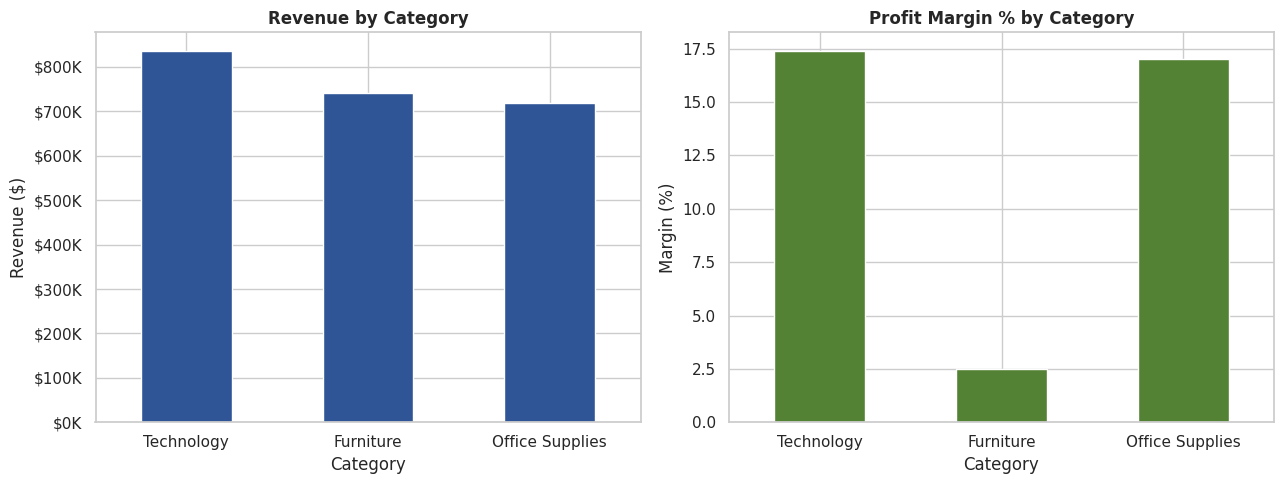

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_summary["Revenue"].plot(kind="bar", ax=axes[0], color="#2F5597")
axes[0].set_title("Revenue by Category")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
axes[0].tick_params(axis="x", rotation=0)

cat_summary["Margin_Pct"].plot(kind="bar", ax=axes[1], color="#548235")
axes[1].set_title("Profit Margin % by Category")
axes[1].set_ylabel("Margin (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("charts/01_category_revenue_margin.png", dpi=120)
plt.show()


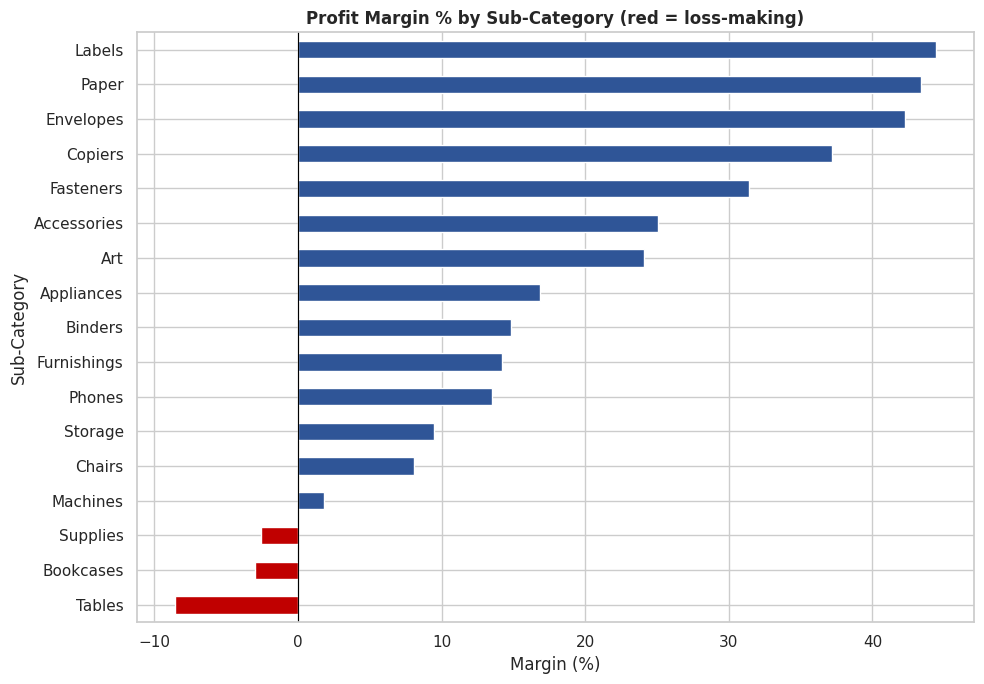

In [5]:
subcat_summary = (
    df.groupby("Sub-Category")
      .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"))
      .assign(Margin_Pct=lambda d: 100 * d["Profit"] / d["Revenue"])
      .sort_values("Margin_Pct")
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#C00000" if v < 0 else "#2F5597" for v in subcat_summary["Margin_Pct"]]
subcat_summary["Margin_Pct"].plot(kind="barh", ax=ax, color=colors)
ax.set_title("Profit Margin % by Sub-Category (red = loss-making)")
ax.set_xlabel("Margin (%)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("charts/02_subcategory_margin.png", dpi=120)
plt.show()


**Insight:** Tables and Bookcases (Furniture) run negative margins despite decent revenue —
likely driven by heavy discounting. Copiers, Labels, and Paper are the standout performers on
margin. This is worth a callout in the final insights doc.

## 3. Top Products by Revenue

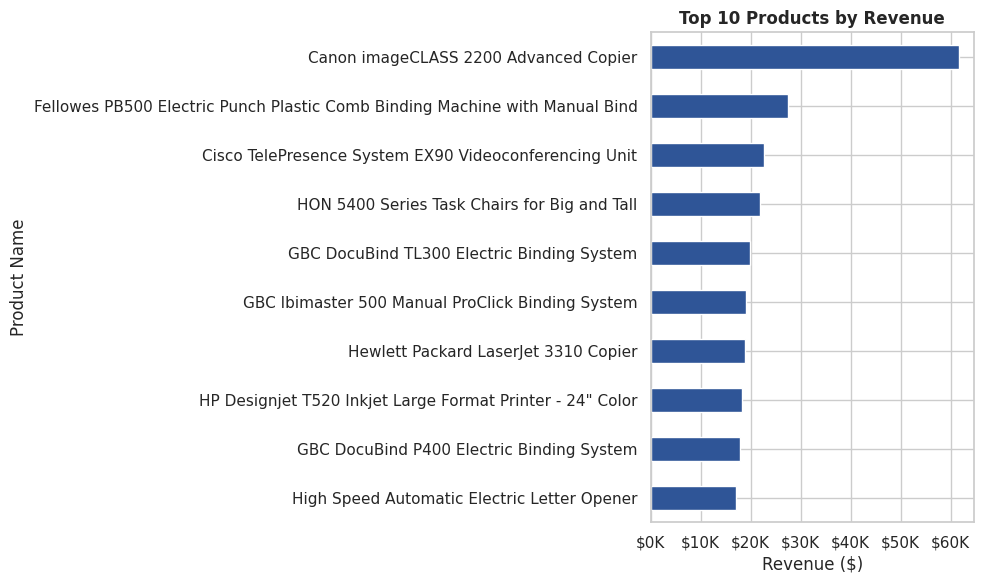

,Revenue,Profit,Units
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"27,453.38","7,753.04",31
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6
HON 5400 Series Task Chairs for Big and Tall,"21,870.58",0.00,39
GBC DocuBind TL300 Electric Binding System,"19,823.48","2,233.51",37
GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98,48
Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90","4,094.98",12
GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27


In [6]:
top_products = (
    df.groupby("Product Name")
      .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"), Units=("Quantity", "sum"))
      .sort_values("Revenue", ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_products["Revenue"].sort_values().plot(kind="barh", ax=ax, color="#2F5597")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
plt.tight_layout()
plt.savefig("charts/03_top_products.png", dpi=120)
plt.show()

top_products


## 4. Regional Performance

Answers: *Which regions perform best?*

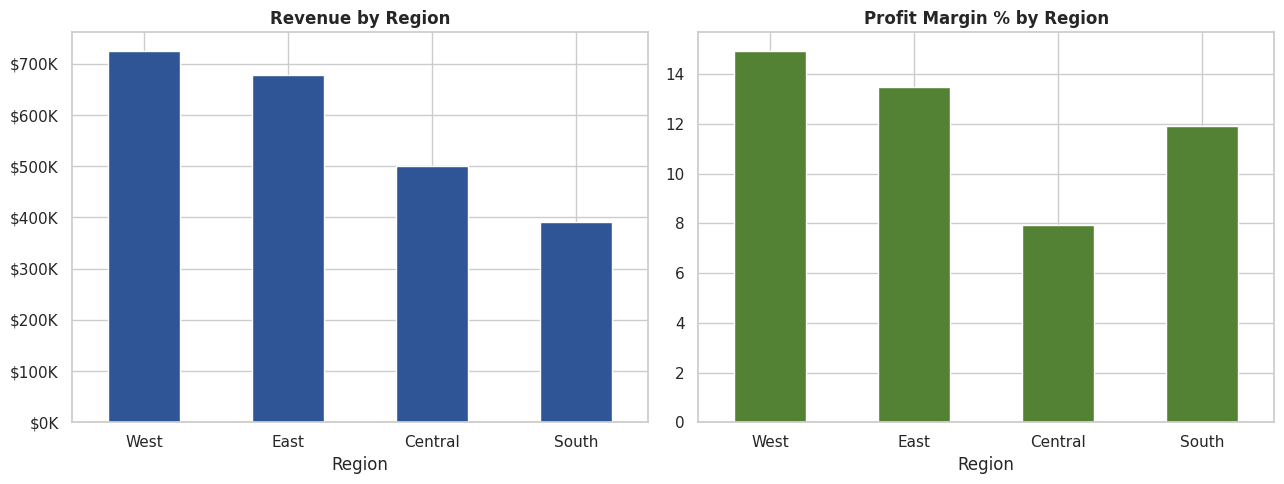

,Revenue,Profit,Orders,Customers,Margin_Pct
Region,,,,,
West,"725,457.82","108,418.45",1611,686,14.94
East,"678,781.24","91,522.78",1401,674,13.48
Central,"501,239.89","39,706.36",1175,629,7.92
South,"391,721.91","46,749.43",822,512,11.93


In [7]:
region_summary = (
    df.groupby("Region")
      .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"),
           Orders=("Order ID", "nunique"), Customers=("Customer ID", "nunique"))
      .assign(Margin_Pct=lambda d: 100 * d["Profit"] / d["Revenue"])
      .sort_values("Revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
region_summary["Revenue"].plot(kind="bar", ax=axes[0], color="#2F5597")
axes[0].set_title("Revenue by Region")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
axes[0].tick_params(axis="x", rotation=0)

region_summary["Margin_Pct"].plot(kind="bar", ax=axes[1], color="#548235")
axes[1].set_title("Profit Margin % by Region")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("charts/04_region_performance.png", dpi=120)
plt.show()

region_summary


## 5. Monthly Sales Trend & Seasonality

Answers: *Which months have the highest sales? Where are sales/profit declining?*

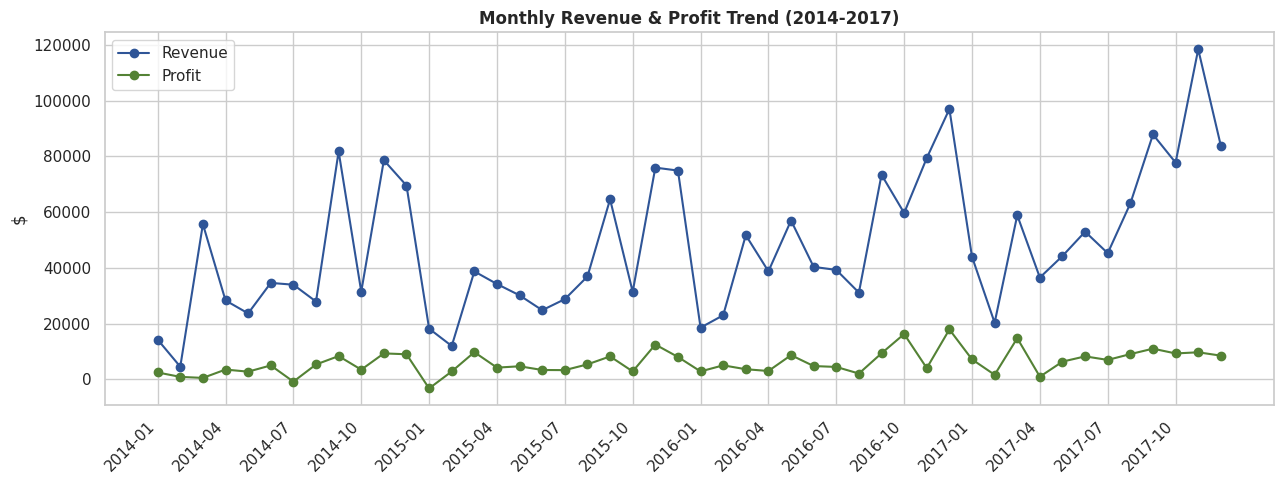

In [8]:
monthly = df.groupby("Order Month").agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly["Revenue"], marker="o", color="#2F5597", label="Revenue")
ax.plot(monthly.index, monthly["Profit"], marker="o", color="#548235", label="Profit")
ax.set_title("Monthly Revenue & Profit Trend (2014-2017)")
ax.set_ylabel("$")
ax.legend()
ax.set_xticks(ax.get_xticks()[::3])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("charts/05_monthly_trend.png", dpi=120)
plt.show()


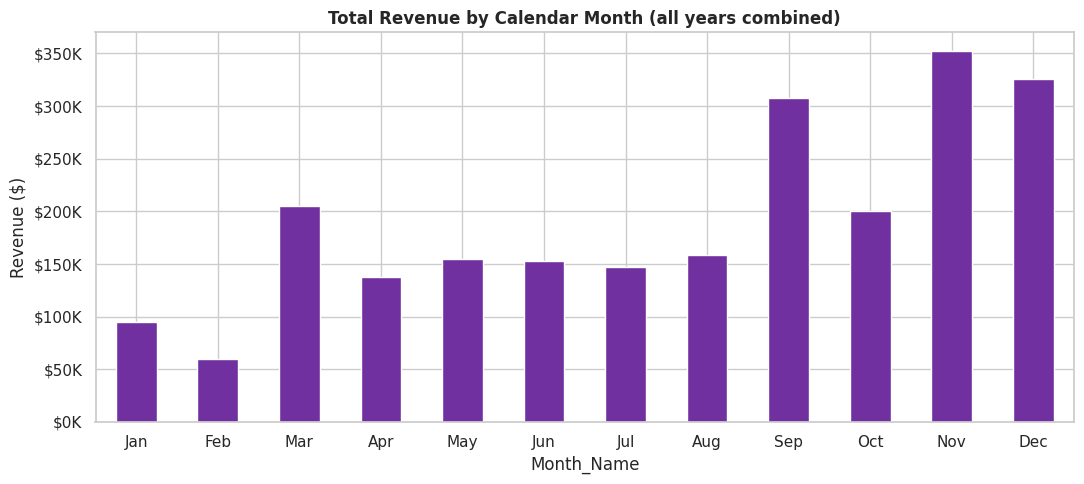

In [9]:
# Seasonality: average revenue by calendar month, across all years
df["Month_Name"] = df["Order Date"].dt.strftime("%b")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal = df.groupby("Month_Name")["Sales"].sum().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 5))
seasonal.plot(kind="bar", ax=ax, color="#7030A0")
ax.set_title("Total Revenue by Calendar Month (all years combined)")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("charts/06_seasonality.png", dpi=120)
plt.show()


**Insight:** Revenue consistently spikes in **November and December** every year — a clear
holiday-season effect worth calling out in the recommendations (e.g. inventory and staffing
planning). September also shows a secondary spike (back-to-office/school buying).

## 6. Year-over-Year Decline Check by Category

Cross-checks the SQL query (`08_declining_sales_profit.sql`) visually.

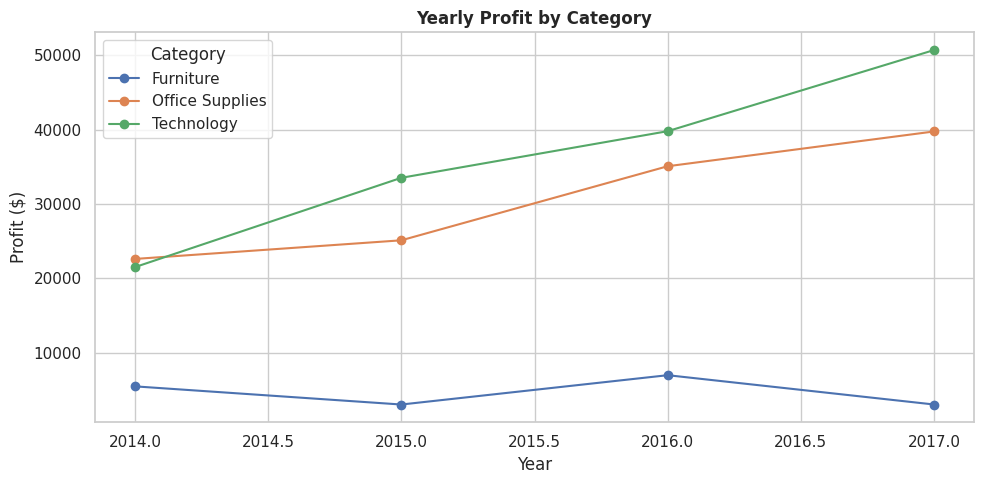

Category,Furniture,Office Supplies,Technology
Order Year,,,
2014,"5,457.73","22,593.42","21,492.83"
2015,"3,015.20","25,099.53","33,503.87"
2016,"6,959.95","35,061.23","39,773.99"
2017,"3,018.39","39,736.62","50,684.26"


In [10]:
yearly_cat = df.groupby(["Order Year", "Category"])["Profit"].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
yearly_cat.plot(kind="line", marker="o", ax=ax)
ax.set_title("Yearly Profit by Category")
ax.set_ylabel("Profit ($)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig("charts/07_yearly_profit_by_category.png", dpi=120)
plt.show()

yearly_cat


**Insight:** Furniture's profit dips in 2015 and again in 2017 even as its revenue keeps
growing — a margin problem, not a demand problem. This lines up with the negative-margin
sub-categories (Tables, Bookcases) found earlier.

## 7. Discount vs. Profit Relationship

A common driver of margin erosion is discounting — let's check the correlation directly.

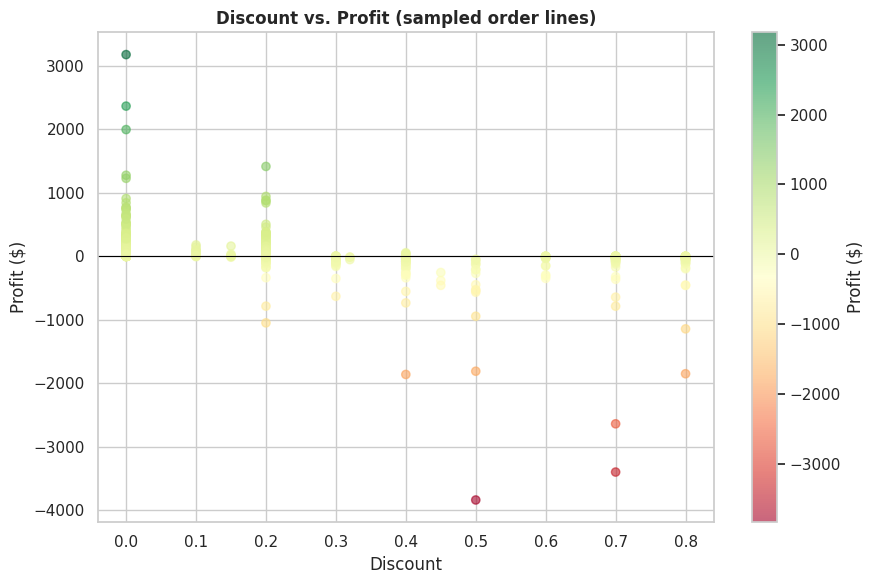

,Discount,Profit,Sales,Quantity
Discount,1.00,-0.22,-0.03,0.01
Profit,-0.22,1.00,0.48,0.07
Sales,-0.03,0.48,1.00,0.20
Quantity,0.01,0.07,0.20,1.00


In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
sample = df.sample(min(2000, len(df)), random_state=42)  # avoid overplotting
scatter = ax.scatter(sample["Discount"], sample["Profit"], c=sample["Profit"], cmap="RdYlGn", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Discount vs. Profit (sampled order lines)")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
plt.colorbar(scatter, label="Profit ($)")
plt.tight_layout()
plt.savefig("charts/08_discount_vs_profit.png", dpi=120)
plt.show()

corr = df[["Discount", "Profit", "Sales", "Quantity"]].corr()
corr


**Insight:** Profit turns negative once discounts climb past roughly 20-30% — a strong
candidate for a "cap discounts above X%" recommendation later.

## 8. Market Basket Analysis — Products Frequently Bought Together

Answers: *Which products are frequently bought together?* using the Apriori algorithm
(association rule mining) on real order baskets — a step up from the simple pairwise SQL count.
We work at the **Sub-Category** level first (product-level is too sparse — 1,862 unique products
across only 5,009 orders means almost no exact product repeats within a basket).

In [12]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Build one "basket" per order, listing which sub-categories it contains
baskets = df.groupby("Order ID")["Sub-Category"].apply(lambda x: list(set(x))).tolist()

te = TransactionEncoder()
te_data = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_data, columns=te.columns_)

frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)

rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)


,antecedents,consequents,support,confidence,lift
1,frozenset({Binders}),frozenset({Appliances}),0.03,0.10,1.10
0,frozenset({Appliances}),frozenset({Binders}),0.03,0.29,1.10
4,frozenset({Phones}),frozenset({Art}),0.02,0.15,1.04
5,frozenset({Art}),frozenset({Phones}),0.02,0.17,1.04
6,frozenset({Furnishings}),frozenset({Phones}),0.03,0.17,1.04
7,frozenset({Phones}),frozenset({Furnishings}),0.03,0.18,1.04
2,frozenset({Appliances}),frozenset({Paper}),0.02,0.24,1.02
3,frozenset({Paper}),frozenset({Appliances}),0.02,0.09,1.02
9,frozenset({Furnishings}),frozenset({Storage}),0.03,0.16,1.01
8,frozenset({Storage}),frozenset({Furnishings}),0.03,0.18,1.01


**How to read this:** `lift > 1` means the two sub-categories are bought together *more
often than chance* would predict. `confidence` is "if a customer buys the antecedent, what % of
the time do they also buy the consequent." These pairs are good candidates for cross-sell
placement or bundled promotions.

## 9. Summary of Key EDA Findings

- **Copiers, Labels, and Paper** are the strongest performers on profit margin; **Tables and
  Bookcases** are structurally loss-making.
- **West and East** regions lead on both revenue and margin; **Central** lags on margin despite
  solid revenue — worth investigating pricing/discount policy there specifically.
- **November–December** is a clear seasonal peak every year — relevant for inventory and
  marketing spend timing.
- **Furniture's profit is declining even as revenue grows** — a margin/discounting problem
  concentrated in specific sub-categories.
- **Heavy discounting (>20-30%) reliably turns orders unprofitable** — a natural, data-backed
  recommendation.
- Association rules surface real cross-sell pairs at the sub-category level for bundling ideas.

*(Full write-up with recommendations goes in the Business Insights document — Phase 6.)*